In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/students_cleaned.csv').dropna()

# Define columns to drop
cols_to_drop = ['region_East Midlands Region', 'region_Ireland', 'region_London Region', 
                'region_North Region', 'region_North Western Region', 'region_Scotland', 
                'region_South East Region', 'region_South Region', 'region_South West Region', 
                'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 
                'code_module_y_BBB', 'code_module_y_CCC', 'code_module_y_DDD', 
                'code_module_y_EEE', 'code_module_y_FFF', 'code_module_y_GGG']

# Only drop columns that exist
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

### first 10 is adiquate

Explained variance ratio: [0.21500083 0.10314692 0.08491942 0.08196922 0.07772031 0.0732667
 0.06820378 0.06651071 0.05866619 0.05518604 0.04144808 0.02352655
 0.01985253 0.01805448 0.00654931 0.00307003 0.0029089 ]
Total variance explained: 1.0000


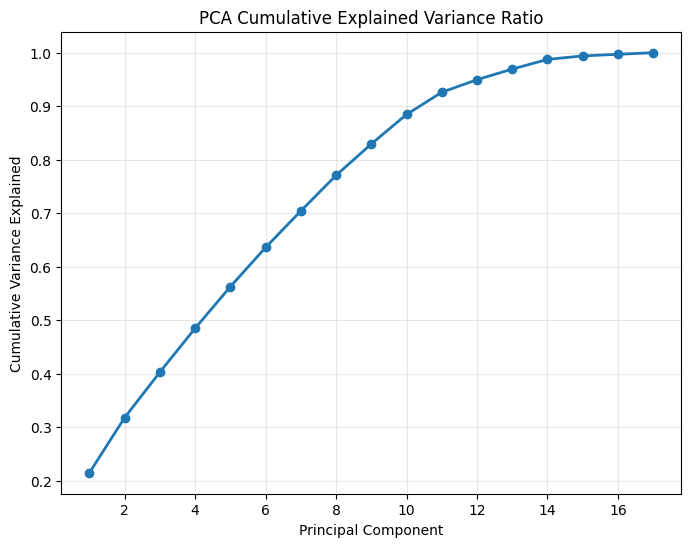

In [ ]:
pca = PCA(n_components=17, random_state=42)
pca_results = pca.fit_transform(data.drop(columns=['final_result']))

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

train_labels = data['final_result']

# Visualize PCA components importatnce
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Cumulative Explained Variance Ratio')
plt.grid(True, alpha=0.3)
plt.show()


In [3]:
data_pca = pd.DataFrame(PCA(n_components=5, random_state=42).fit_transform(data.drop(columns=['final_result'])), columns=[f'PC{i+1}' for i in range(5)])

training_data, test_data = train_test_split(data_pca, test_size=0.2, random_state=42)
# training_data, val_data = train_test_split(training_val, test_size=0.2, random_state=42)

In [6]:
feature_cols = [c for c in training_data.columns if c != "final_result"]
train_X = training_data[feature_cols]
# val_X = val_data[feature_cols]

In [17]:
# eps_values = [round(x, 2) for x in np.linspace(1.5, 2.2, num=6)]
min_samples_values = range(1, 10)

results = []
index = 0
# for eps in eps_values:
for min_samples in min_samples_values:
    clusterer = make_pipeline(HDBSCAN( min_samples=min_samples, metric='euclidean'))
    
    # Fit on training set only
    train_labels = clusterer.fit_predict(train_X)
    n_clusters_train = len(set(train_labels)) - (1 if -1 in train_labels else 0)
    n_noise_train = list(train_labels).count(-1)
    

    # scan on validation set       
    silhouette_score_val = silhouette_score(train_X, train_labels) if n_clusters_train > 1 else -1
    davies_bouldin_score_val = davies_bouldin_score(train_X, train_labels) if n_clusters_train > 1 else -1
    # calinski_harabasz_score_val = calinski_harabasz_score(train_X, train_labels) if n_clusters
    
    results.append({
        "min_samples": min_samples,
        "n_clusters_train": n_clusters_train,
        "n_noise_train": n_noise_train,
        "silhouette_score_val": silhouette_score_val,
        "davies_bouldin_score_val": davies_bouldin_score_val
    })
    print(f"Tested min_samples={min_samples} -> {n_clusters_train} clusters (train), {n_noise_train} noise")
    print(f"Completed {((index+1)/(len(min_samples_values)))*100}%")
    index += 1
results_df = pd.DataFrame(results)


Tested min_samples=1 -> 2 clusters (train), 15 noise
Completed 11.11111111111111%
Tested min_samples=2 -> 2 clusters (train), 15 noise
Completed 22.22222222222222%
Tested min_samples=3 -> 2 clusters (train), 21 noise
Completed 33.33333333333333%
Tested min_samples=4 -> 2 clusters (train), 24 noise
Completed 44.44444444444444%
Tested min_samples=5 -> 2 clusters (train), 30 noise
Completed 55.55555555555556%
Tested min_samples=6 -> 8 clusters (train), 3453 noise
Completed 66.66666666666666%
Tested min_samples=7 -> 3 clusters (train), 3592 noise
Completed 77.77777777777779%
Tested min_samples=8 -> 3 clusters (train), 4664 noise
Completed 88.88888888888889%
Tested min_samples=9 -> 3 clusters (train), 4965 noise
Completed 100.0%


In [15]:
pivot_silhouette = results_df.pivot_table(
    values='silhouette_score_val',
    index='min_samples',
    columns='eps'
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_silhouette, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Silhouette Score')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.title('Silhouette Score vs eps and min_samples')
plt.xticks(range(len(pivot_silhouette.columns)), [f'{x:.2f}' for x in pivot_silhouette.columns], rotation=45)
plt.yticks(range(len(pivot_silhouette.index)), pivot_silhouette.index)
plt.tight_layout()
plt.show()

KeyError: 'eps'

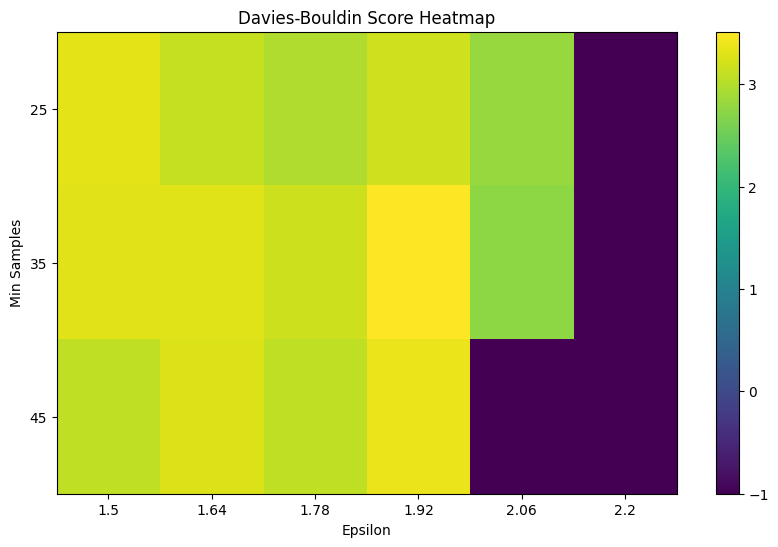

In [ ]:
pivot_davies = results_df.pivot_table(index='min_samples', columns='eps', values='davies_bouldin_score_val')

plt.figure(figsize=(10, 6))
plt.imshow(pivot_davies, cmap='viridis', aspect='auto')
plt.bar_label = plt.colorbar()
plt.title('Davies-Bouldin Score Heatmap')
plt.xlabel('Epsilon')
plt.ylabel('Min Samples')
plt.xticks(ticks=np.arange(len(pivot_davies.columns)), labels=pivot_davies.columns)
plt.yticks(ticks=np.arange(len(pivot_davies.index)), labels=pivot_davies.index)
plt.show()

In [10]:
clusterer = make_pipeline(HDBSCAN(min_samples=40, metric='euclidean'))
        
train_labels = clusterer.fit_predict(train_X)

In [11]:

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(train_X)


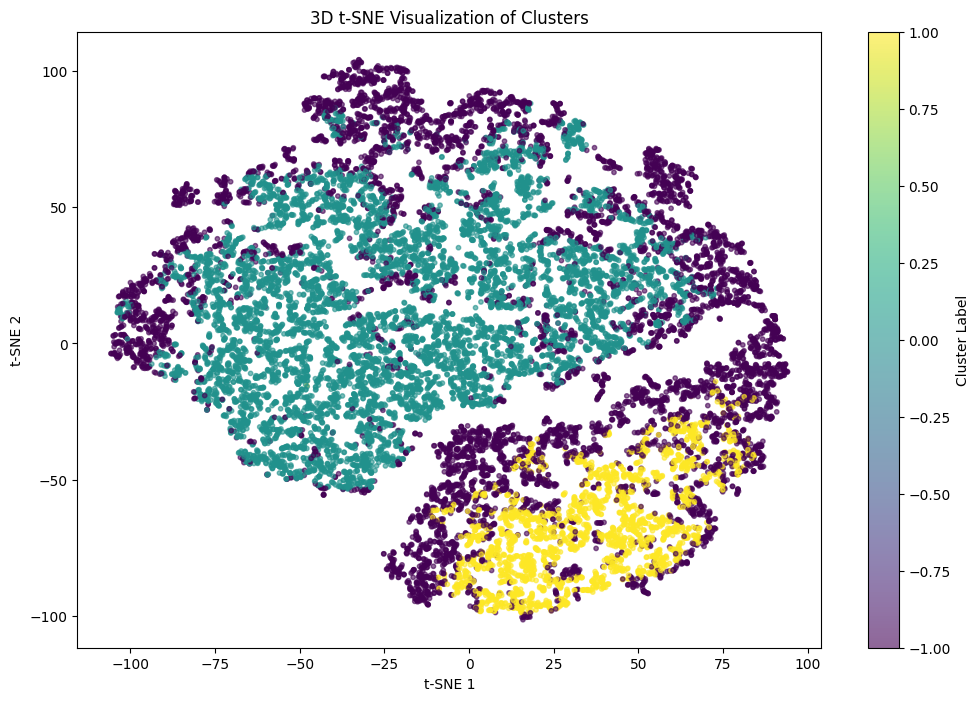

In [12]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], 
                     c=train_labels, cmap='viridis', s=10, alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('3D t-SNE Visualization of Clusters')
plt.colorbar(scatter, ax=ax, label='Cluster Label')
plt.show()